Ukrywanie obrazu:

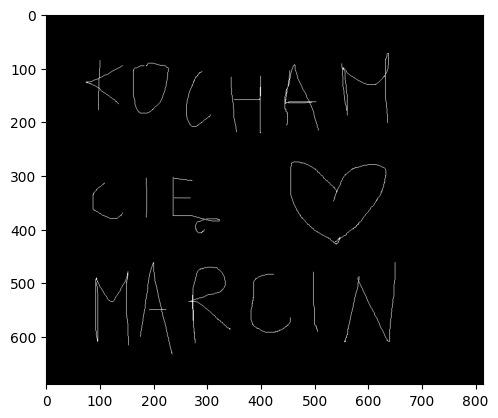

[  0 255]


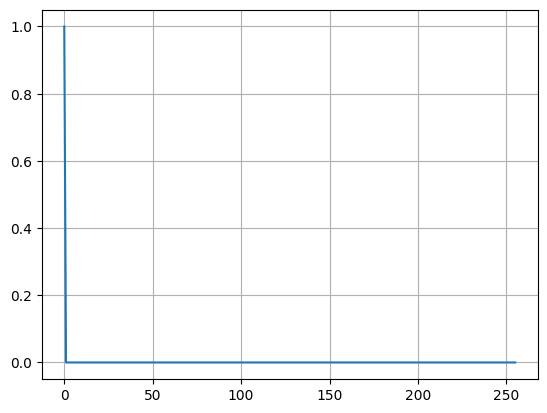

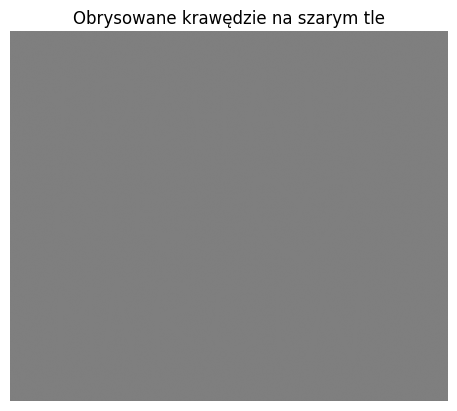

[127 128]


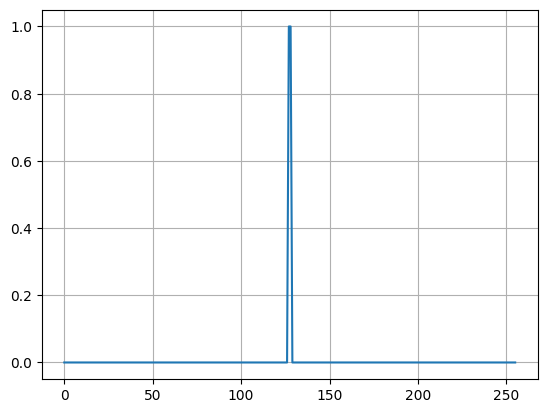

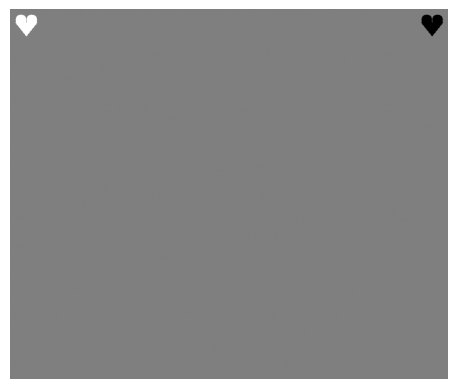

[  0 127 128 255]


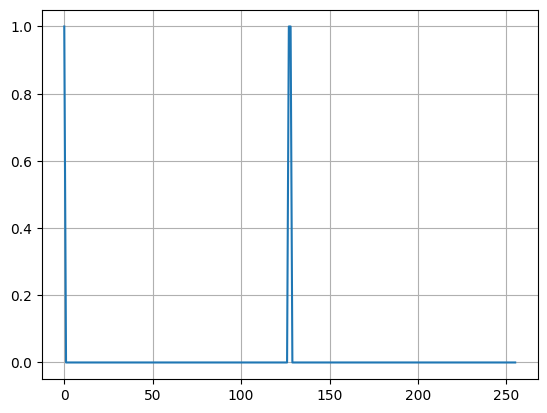

True

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("wiadomosc.bmp", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, "gray")
plt.show()

def show_binary_hist(img):
    hist = cv2.calcHist([img], [0], None, [256], [0, 255])
    hist_binary = (hist > 0).astype(int)
    print(np.unique(img))
    plt.plot(hist_binary)
    plt.grid()
    plt.show()

show_binary_hist(img)
edges = cv2.Laplacian(img, cv2.CV_8U, ksize=3)
edges = cv2.convertScaleAbs(edges)

background_gray = 127
edge_gray = 128

secret = np.full_like(img, background_gray, dtype=np.uint8)
secret[edges > 0] = edge_gray

plt.imshow(secret, cmap='gray', vmin=0, vmax=255)
plt.title("Obrysowane krawędzie na szarym tle")
plt.axis('off')
plt.show()

cv2.imwrite("secret.bmp", secret)
show_binary_hist(secret)

h = secret.shape[0]
w = secret.shape[1]

def draw_heart(img, center, size=20, color=0):
    x, y = center
    cv2.circle(img, (x - size//2, y - size//2), size//2, color, -1)
    cv2.circle(img, (x + size//2, y - size//2), size//2, color, -1)
    pts = np.array([[x - size, y - size//4], [x + size, y - size//4], [x, y + size]], np.int32)
    cv2.fillPoly(img, [pts], color)

draw_heart(secret, center=(w-30, 30), size=20, color=0)
draw_heart(secret, center=(30, 30), size=20, color=255)

plt.imshow(secret, cmap='gray', label="Lmao")
plt.axis('off')
plt.show()

show_binary_hist(secret)
cv2.imwrite("secret_with_hearts.bmp", secret)

Odkrywanie obrazu:

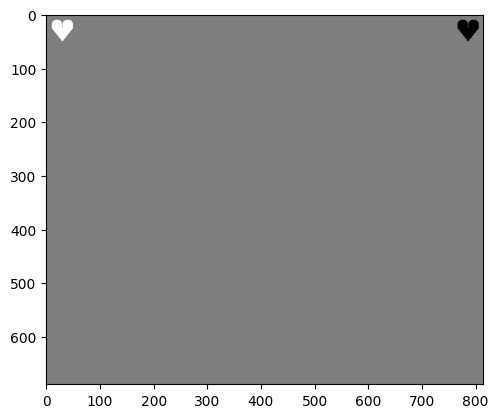

[  0 127 128 255]


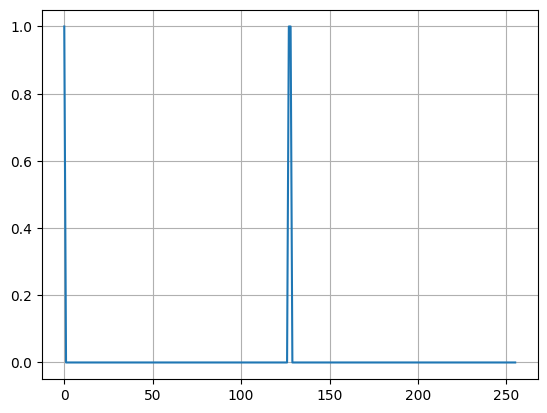

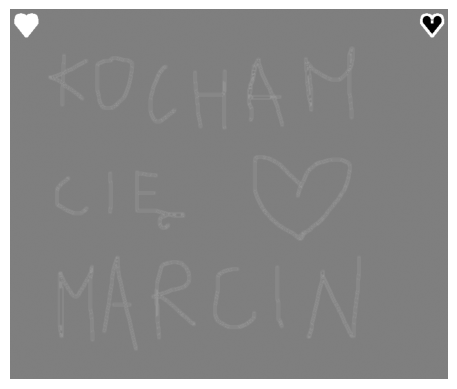

[  0 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 172 254 255]


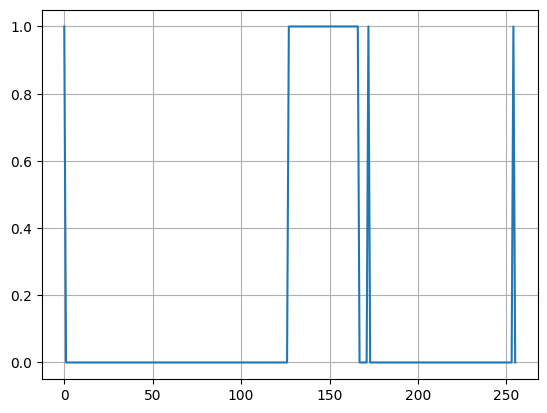

In [7]:
img = cv2.imread("secret_with_hearts.bmp", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, 'gray')
plt.show()

show_binary_hist(img)

lap = cv2.Laplacian(img, cv2.CV_16S, ksize=5)
lap_abs = cv2.convertScaleAbs(lap)
enhanced = cv2.add(img, lap_abs)
enhanced_norm = cv2.normalize(enhanced, None, 0, 255, cv2.NORM_MINMAX)

plt.imshow(enhanced_norm, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

show_binary_hist(enhanced_norm)